<table  align="left" width="100%"> <tr>
        <td  style="background-color:#ffffff;"><a href="https://qworld.net" target="_blank"><img src="../images/qworld/qworld.jpg" width="35%" align="left"></a></td>
        <td  align="right" style="background-color:#ffffff;vertical-align:bottom;horizontal-align:right">
            prepared by Adam Glos and Özlem Salehi Köken
        </td>        
</tr></table>

# <font color="blue"> Solutions for </font> Grover Algorithm for Max-Cut Problem

<a id="task1"> </a>

### Task 1

Implement the Grover algorithm for the following graph
<img src="../images/completebipartite.png" width="25%" align="center">

and check whether there is a coloring in which there are exactly four edges connecting vertices with a different color. Apply the oracle twice.

<h3> Solution </h3>

In [4]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator

# 0-3: vertices
# 4-7: edge checking
# 8-10: the number
# 11: auxillary

def edge_check(temp_qc, a, b, c):
    temp_qc.cx(a, c)
    temp_qc.cx(b, c)

def oracle_computation():
    # check all edges
    temp_qc = QuantumCircuit(12)

    edge_check(temp_qc,0, 2, 4)
    edge_check(temp_qc,0, 3, 5)
    edge_check(temp_qc,1, 2, 6)
    edge_check(temp_qc,1, 3, 7)
    
    # add outputs of edge checking
    temp_qc.cx(4, 8)
    
    temp_qc.ccx(5, 8, 9)
    temp_qc.cx(5, 8)
    
    temp_qc.ccx(6, 8, 9)
    temp_qc.cx(6, 8)

    temp_qc.mcx([7,8,9], 10)
    temp_qc.ccx(7, 8, 9)
    temp_qc.cx(7,8)
    
    # check if number stored in q10 q9 q8 is equal to four 
    temp_qc.x(9)
    temp_qc.x(8)
    
    # note we don't have to undo the X gates as they will be undone by the inverse of the oracle computation

    temp_qc.mcx([8,9,10], 11)
    
    return temp_qc

def oracle(qc):    
    qc.append(oracle_computation(), range(12))
    qc.z(11)
    qc.append(oracle_computation().inverse(), range(12))
    
def grover_diffusion(qc):
    qc.h(range(4))
    qc.x(range(4))
    qc.append(ZGate().control(3), range(4))
    qc.x(range(4))
    qc.h(range(4))

# the Grover algorithm
qc = QuantumCircuit(12, 4)
qc.h(range(4))

for i in range(2):
    oracle(qc)
    grover_diffusion(qc)

qc.measure(range(4), range(4))

trials = 10000

tqc = transpile(qc, AerSimulator())
job = AerSimulator().run(tqc, shots=trials)
counts = job.result().get_counts(tqc)


print("Random guess probability:", 1./2**4)

for state, c in counts.items():
    print("Probability of obsering", state, ": " ,c/trials)

Random guess probability: 0.0625
Probability of obsering 1001 :  0.0043
Probability of obsering 0010 :  0.0039
Probability of obsering 1000 :  0.0037
Probability of obsering 0000 :  0.0035
Probability of obsering 1011 :  0.0051
Probability of obsering 0101 :  0.0037
Probability of obsering 1010 :  0.0031
Probability of obsering 0100 :  0.0046
Probability of obsering 1100 :  0.4815
Probability of obsering 1110 :  0.0032
Probability of obsering 0110 :  0.0035
Probability of obsering 0011 :  0.463
Probability of obsering 0001 :  0.004
Probability of obsering 1111 :  0.0029
Probability of obsering 1101 :  0.0057
Probability of obsering 0111 :  0.0043


We observe that the probability of observing either "1100" and "0011" is around 95%. These two colorings correspond to the case where the nodes 0 and 1 are colored using the first color, and 2 and 3 are colored using the second color.  

<a id="task2"></a>
### Task 2

Implement the Grover Algorithm for the following graph
<img src="../images/finalgrover1.png" width="25%" align="center">

and check whether there is coloring with six or more edges connecting vertices with a different color. Apply the oracle twice. 

*Hint*: Note that you have to check only two bits of the number.

<h3> Solution </h3>

Random guess probability: 0.03125


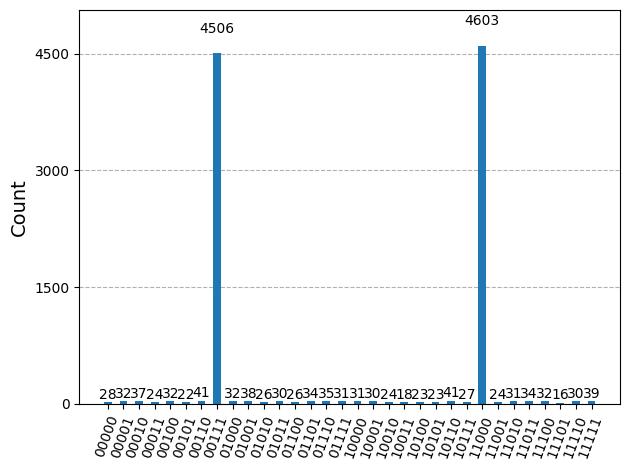

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import ZGate
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# 0-4: vertices
# 5-11: edge checking
# 12-14: the number
# 15: auxillary

def edge_check(temp_qc, a, b, c):
    temp_qc.cx(a, c)
    temp_qc.cx(b, c)

def oracle_computation():
    # check all edges

    temp_qc = QuantumCircuit(16)

    edge_check(temp_qc, 0, 1, 5)
    edge_check(temp_qc, 0, 3, 6)
    edge_check(temp_qc, 0, 4, 7)
    edge_check(temp_qc, 1, 3, 8)
    edge_check(temp_qc, 1, 4, 9)
    edge_check(temp_qc, 2, 3, 10)
    edge_check(temp_qc, 2, 4, 11)
    
    # add qubit 5   
    temp_qc.cx(5, 12)
    
    # add qubits 6-7
    for j in range(6,8):
        temp_qc.ccx(j, 12, 13)
        temp_qc.cx(j, 12)
    
    # add qubits 8-11
    for j in range(8,12):
        temp_qc.mcx([j, 12, 13], 14)
        temp_qc.ccx(j, 12, 13)
        temp_qc.cx(j, 12)

    # set the last bit 
    # we do not have to check 12th qubit
    temp_qc.ccx(13, 14, 15)
    
    return temp_qc

def oracle(qc):    
    qc.append(oracle_computation(), range(16))
    qc.z(15)
    qc.append(oracle_computation().inverse(), range(16))

def grover_diffusion(qc):
    qc.h(range(5))
    qc.x(range(5))
    qc.append(ZGate().control(4), range(5))
    qc.x(range(5))
    qc.h(range(5))


# the Grover algorithm
qc = QuantumCircuit(16, 5)
qc.h(range(5))

for i in range(2):
    oracle(qc)
    grover_diffusion(qc)
       
qc.measure(range(5), range(5))

trials = 10000

tqc = transpile(qc, AerSimulator())
job = AerSimulator().run(tqc, shots=trials)
counts = job.result().get_counts(tqc)


print("Random guess probability:", 1./2**5)

plot_histogram(counts)